# **Data Preparation**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

#### Helper functions

These are used throughout the notebook to avoid rewriting the same logic multiple times, and to make sure every statistic used for cleaning/imputation is **fit on the training set only** and then applied identically to both train and test — this avoids leaking information from the test set into the cleaning pipeline.

In [2]:
def plot_correlation_heatmap(data, title, exclude_prefixes=("Cat:", "Rank:")):
    """Plot a lower-triangle correlation heatmap of numeric columns, excluding given prefixes."""
    numeric_df = data.select_dtypes(include="number")
    cols_to_drop = [c for c in numeric_df.columns if any(c.startswith(p) for p in exclude_prefixes)]
    numeric_df = numeric_df.drop(columns=cols_to_drop, errors="ignore")

    corr_matrix = numeric_df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    plt.figure(figsize=(14, 10))
    sns.set_style("whitegrid")
    sns.heatmap(
        corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
        cbar=True, square=True, linewidths=0.5, annot_kws={"size": 8}
    )
    plt.title(title, fontsize=16, pad=12)
    plt.tight_layout()
    plt.show()


def fit_iqr_bound(train_df, col, k=5.0):
    """Compute an IQR-based upper outlier bound using TRAIN data only."""
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q3 + k * IQR


def fit_category_medians(train_df, col, cat_cols, positive_only=True):
    """Fit per-category medians (+ a global fallback median) for imputation, using TRAIN data only."""
    valid = train_df[train_df[col] > 0] if positive_only else train_df[train_df[col].notna()]
    global_median = valid[col].median()

    cat_medians = {}
    for cat in cat_cols:
        med = valid.loc[valid[cat] == 1, col].median()
        if not pd.isna(med):
            cat_medians[cat] = med

    return cat_medians, global_median


def apply_category_imputation(df, col, cat_cols, cat_medians, global_median, mask):
    """Impute df[col] at `mask` positions using medians that were fit on train data."""
    def get_value(row):
        active = [cat_medians[c] for c in cat_cols if row[c] == 1 and c in cat_medians]
        return np.mean(active) if active else global_median

    df.loc[mask, col] = df.loc[mask].apply(get_value, axis=1)
    return df

In [3]:
file_name = "../data/DM1_game_dataset.csv"
df = pd.read_csv(file_name)

#### Correlation matrix before cleaning

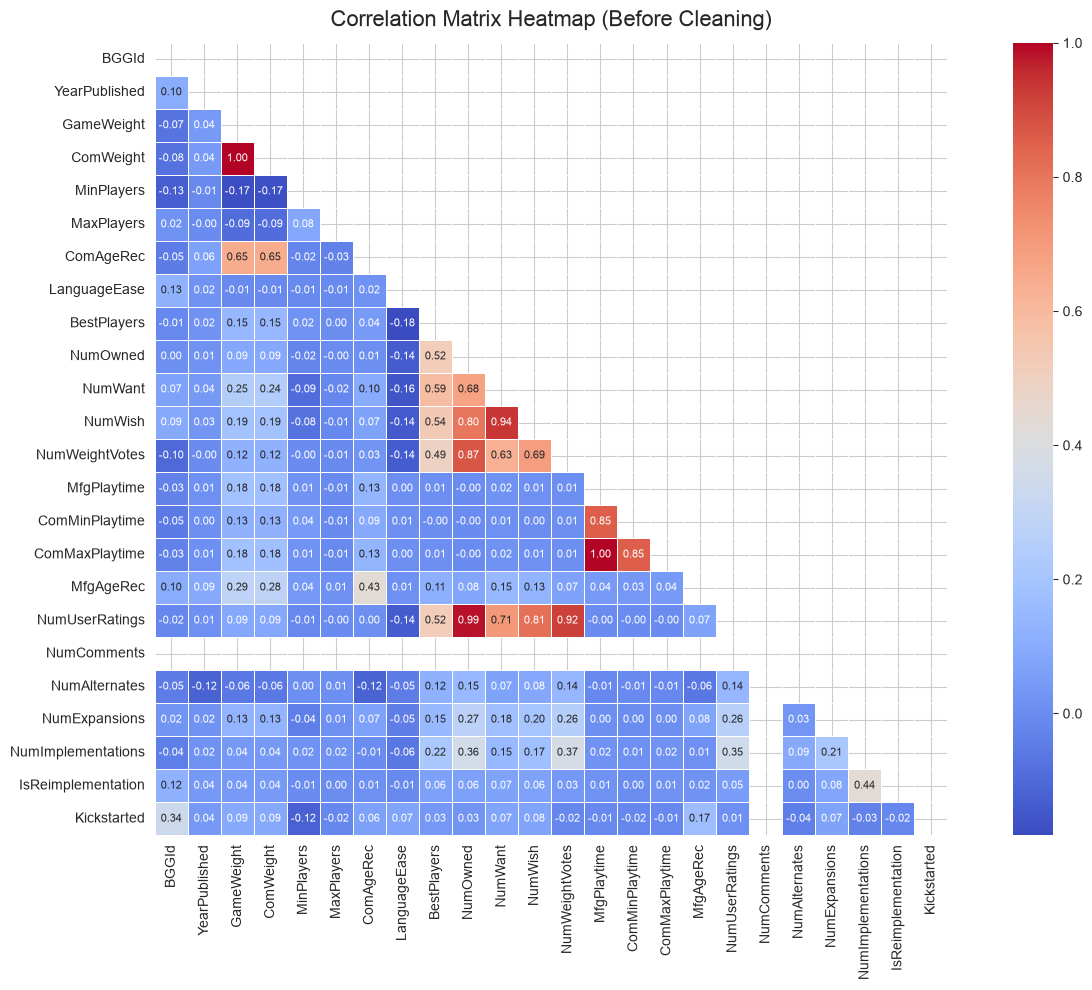

In [4]:
plot_correlation_heatmap(df, "Correlation Matrix Heatmap (Before Cleaning)")

#### Remove the following features we selected in the data understanding part:

- **Description**: it's a textual feature so we don't need it for our analysis
- **BestPlayers**: contains more than 90% of 0s
- **GoodPlayers**: contains more than 90% of empty arrays
- **NumComments**: contains 100% of 0s
- **ImagePath**: contains urls (not relevant)
- **MfgPlaytime**: 1.0 correlation with ComMaxPlaytime
- **Family**: contains almost 70% of missing values

In [5]:
df = df.drop(["Description", "BestPlayers", "GoodPlayers", "NumComments", "ImagePath", "MfgPlaytime", "Family"], axis=1)
df.head()

,BGGId,Name,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,NumOwned,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,2014,1.8333,2.0512,2,4,8.0,213.0,528,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,2021,1.0000,1.2256,2,5,8.0,36.0,72,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,2020,3.6667,3.8190,1,5,NaN,NaN,834,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,2004,1.3077,1.4216,2,2,7.0,NaN,154,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,2019,1.5000,1.6230,2,4,NaN,7.0,208,...,21926,0,0,0,0,0,0,0,0,Medium


####  Label encoding: replace 'low', 'medium', 'high' values in **Rating** with 1, 2, 3

In [6]:
rating_map = {'Low': 1, 'Medium': 2, 'High': 3}
df['Rating'] = df['Rating'].map(rating_map)
df['Rating']

0        1
1        2
2        3
3        1
4        2
        ..
21920    1
21921    2
21922    1
21923    3
21924    1
Name: Rating, Length: 21925, dtype: int64

#### Filter **'YearPublished'** by removing games published before 1950

In [7]:
# count how many rows have 'YearPublished' before 1950
df_1950 = df[(df['YearPublished'] >= 1950)]
print(f"Number of rows with 'YearPublished' before 1950: {len(df) - len(df_1950)}")

Number of rows with 'YearPublished' before 1950: 406


In [8]:
# drop rows where 'YearPublished' is before 1950
df = df[df['YearPublished'] >= 1950]
df['YearPublished']

0        2014
1        2021
2        2020
3        2004
4        2019
         ... 
21920    1998
21921    2004
21922    1993
21923    2015
21924    1989
Name: YearPublished, Length: 21519, dtype: int64

#### Handling outliers and logical inconsistencies in **'ComMinPlaytime'** and **'ComMaxPlaytime'**

In [9]:
# Define target columns and category columns
playtime_cols = ["ComMinPlaytime", "ComMaxPlaytime"]
for col in playtime_cols:
    df[col] = df[col].astype(float)

cat_cols = [col for col in df.columns if col.startswith('Cat:')]

In [10]:
# If Min > Max, drop the rows (a logical contradiction, not a statistic estimated from the data,
# so it's safe to apply before the train/test split)
index_to_drop = df[df['ComMinPlaytime'] > df['ComMaxPlaytime']].index
df.drop(index=index_to_drop, inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Removed rows: {len(index_to_drop)}")
print(f"Remaining rows: {len(df)}")

Removed rows: 150
Remaining rows: 21369


### Train / test split

From this point on, several cleaning steps use statistics estimated **from the data itself** (medians per category, IQR-based outlier bounds). If those statistics were computed on the full dataset, information from the rows that end up in the test set would leak into the cleaning of the training set — inflating how good the pipeline (and later, the model) looks.

To avoid this, we split the data **now**, before any such statistic is computed, and from here onward every fitted value (medians, bounds) is calculated on `train_df` only and then applied identically to both `train_df` and `test_df`. The split is stratified on `Rating`, the intended target variable, to keep its class balance similar in both sets.

In [11]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Rating'])
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")

Train rows: 17095
Test rows:  4274


In [12]:
# Outlier removal (IQR bound fit on TRAIN only, applied to both sets)
# Note: we use a wide multiplier (5.0 instead of the usual 1.5) because playtime is a legitimately
# long-tailed variable (e.g. some titles genuinely run for several hours) — a standard 1.5x IQR would
# remove many valid games. 5.0x targets only the extreme/erroneous values.
for col in playtime_cols:
    upper_bound = fit_iqr_bound(train_df, col, k=5.0)

    before_train, before_test = len(train_df), len(test_df)
    train_df = train_df[train_df[col] <= upper_bound].copy().reset_index(drop=True)
    test_df = test_df[test_df[col] <= upper_bound].copy().reset_index(drop=True)

    print(f"{col}: threshold = {upper_bound:.2f} | removed {before_train - len(train_df)} from train, "
          f"{before_test - len(test_df)} from test")

ComMinPlaytime: threshold = 260.00 | removed 417 from train, 100 from test
ComMaxPlaytime: threshold = 390.00 | removed 161 from train, 39 from test


In [13]:
# Category-based imputation of double-zero rows (medians fit on TRAIN only)
mask_double_zero_train = (train_df['ComMinPlaytime'] == 0.0) & (train_df['ComMaxPlaytime'] == 0.0)
mask_double_zero_test = (test_df['ComMinPlaytime'] == 0.0) & (test_df['ComMaxPlaytime'] == 0.0)
print(f"Imputing {mask_double_zero_train.sum()} rows in train, {mask_double_zero_test.sum()} rows in test...")

for col in playtime_cols:
    cat_medians, global_median = fit_category_medians(train_df, col, cat_cols)
    apply_category_imputation(train_df, col, cat_cols, cat_medians, global_median, mask_double_zero_train)
    apply_category_imputation(test_df, col, cat_cols, cat_medians, global_median, mask_double_zero_test)

print("\nFinal skewness (train set):")
print(f"ComMinPlaytime: {train_df['ComMinPlaytime'].skew():.4f}")
print(f"ComMaxPlaytime: {train_df['ComMaxPlaytime'].skew():.4f}")

Imputing 463 rows in train, 130 rows in test...

Final skewness (train set):
ComMinPlaytime: 2.0844
ComMaxPlaytime: 2.0287


Statistics after cleaning (train set):
       ComMinPlaytime  ComMaxPlaytime
count    16517.000000    16517.000000
mean        50.499516       63.078525
std         46.215896       55.833971
min          0.000000        1.000000
25%         20.000000       30.000000
50%         30.000000       45.000000
75%         60.000000       90.000000
max        250.000000      360.000000


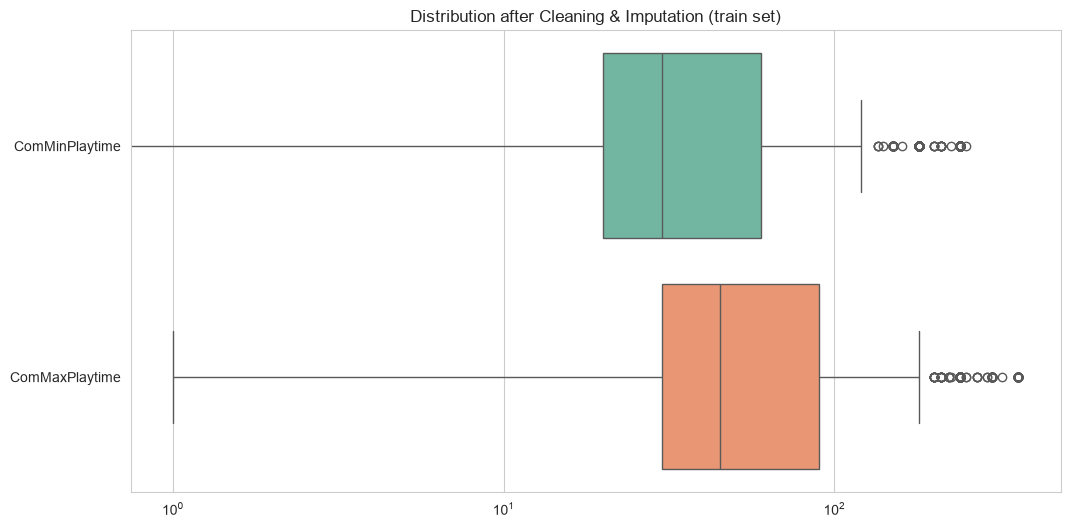

In [14]:
# Statistical summary (train set)
print("Statistics after cleaning (train set):")
print(train_df[playtime_cols].describe())

# Visual check
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_df[playtime_cols], orient="h", palette="Set2")
plt.title("Distribution after Cleaning & Imputation (train set)")
plt.xscale('log')  # Log scale to better visualize the range
plt.show()

#### Merging of '**NumWant**', '**NumOwned**' and '**NumWish**' features

In [15]:
# Purely arithmetic (no fitted statistic involved), so it's safe to apply identically to both sets
for d in (train_df, test_df):
    d['Avg_popularity'] = (d['NumWant'] + d['NumWish'] + d['NumOwned']) / 3

In [16]:
train_df[['Avg_popularity', 'NumWant', 'NumWish', 'NumOwned']]

,Avg_popularity,NumWant,NumWish,NumOwned
0,27.666667,2,15,66
1,74.000000,18,75,129
2,173.666667,8,89,424
3,167.333333,9,52,441
4,767.666667,80,555,1668
...,...,...,...,...
16512,181.000000,24,182,337
16513,707.666667,57,213,1853
16514,1223.666667,89,566,3016
16515,34.666667,4,9,91


In [17]:
for d in (train_df, test_df):
    d.drop(['NumWant', 'NumWish', 'NumOwned'], axis=1, inplace=True)

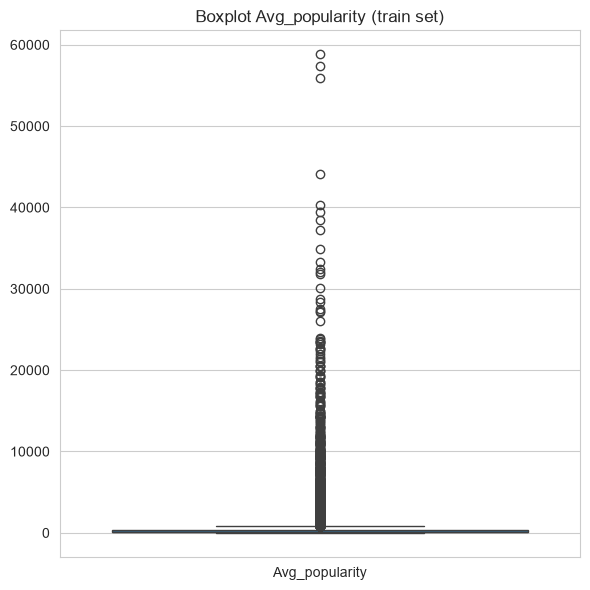

In [18]:
# outlier detection for Avg_popularity (train set)
plt.figure(figsize=(6, 6))
sns.boxplot(data=train_df[["Avg_popularity"]])
plt.title("Boxplot Avg_popularity (train set)")
plt.tight_layout()
plt.show()

In [19]:
train_df["Avg_popularity"].describe()

count    16517.000000
mean       603.451656
std       2092.538212
min          2.333333
25%         60.000000
50%        128.666667
75%        375.000000
max      58817.000000
Name: Avg_popularity, dtype: float64

In [20]:
# log1p is a fixed deterministic transform (no parameters estimated from the data), safe for both sets
for d in (train_df, test_df):
    d["Avg_popularity_log"] = np.log1p(d["Avg_popularity"])
    d.drop("Avg_popularity", axis=1, inplace=True)

In [21]:
train_df["Avg_popularity_log"].describe()

count    16517.000000
mean         5.127211
std          1.367859
min          1.203973
25%          4.110874
50%          4.864967
75%          5.929589
max         10.982203
Name: Avg_popularity_log, dtype: float64

#### Dropping **ComWeight** bc of extremely high correlation (almost 1) with **GameWeight**

In [22]:
for d in (train_df, test_df):
    d.drop(['ComWeight'], axis=1, inplace=True)

#### Dropping **'LanguageEase'**

In [23]:
# dropping LanguageEase because of semantic discrepancy between variable description and actual data
# + 26% of missing values
for d in (train_df, test_df):
    d.drop(['LanguageEase'], axis=1, inplace=True)

#### Dropping **'GameWeight'** Zero values (range is 1-5)

In [24]:
# drop rows with 0 in 'GameWeight' as they are likely missing data
before_train, before_test = len(train_df), len(test_df)
train_df = train_df[train_df['GameWeight'] != 0].reset_index(drop=True)
test_df = test_df[test_df['GameWeight'] != 0].reset_index(drop=True)

print(f"Number of removed rows: {before_train - len(train_df)} (train), {before_test - len(test_df)} (test)")

Number of removed rows: 384 (train), 91 (test)


#### Handling logical inconsistencies and Zero values in **'MinPlayers'** and **'MaxPlayers'**

In [25]:
train_df[["MinPlayers", "MaxPlayers"]].describe()

,MinPlayers,MaxPlayers
count,16133.000000,16133.000000
mean,2.012521,5.711833
std,0.687436,16.348231
min,0.000000,0.000000
25%,2.000000,4.000000
50%,2.000000,4.000000
75%,2.000000,6.000000
max,10.000000,999.000000


In [26]:
# Drop rows where MinPlayers > MaxPlayers (logical contradiction, not a fitted statistic)
before_train, before_test = len(train_df), len(test_df)
train_df = train_df[train_df['MinPlayers'] <= train_df['MaxPlayers']].reset_index(drop=True)
test_df = test_df[test_df['MinPlayers'] <= test_df['MaxPlayers']].reset_index(drop=True)

print(f"Removed rows (Min > Max): {before_train - len(train_df)} (train), {before_test - len(test_df)} (test)")

Removed rows (Min > Max): 74 (train), 27 (test)


In [27]:
# Count rows where both MinPlayers and MaxPlayers are zero, and check initial skewness (train set)
mask_players_zero_train = (train_df['MinPlayers'] == 0) & (train_df['MaxPlayers'] == 0)
print(f"Rows with both MinPlayers and MaxPlayers at zero (train): {mask_players_zero_train.sum()}")
print(f"Initial Skewness MinPlayers: {train_df['MinPlayers'].skew():.4f}")
print(f"Initial Skewness MaxPlayers: {train_df['MaxPlayers'].skew():.4f}")

Rows with both MinPlayers and MaxPlayers at zero (train): 24
Initial Skewness MinPlayers: 1.6630
Initial Skewness MaxPlayers: 43.7292


In [28]:
# 1. Remove double-zero rows (cleaner than imputing so few rows) from both sets
before_train, before_test = len(train_df), len(test_df)
train_df = train_df[~((train_df['MinPlayers'] == 0) & (train_df['MaxPlayers'] == 0))].reset_index(drop=True)
test_df = test_df[~((test_df['MinPlayers'] == 0) & (test_df['MaxPlayers'] == 0))].reset_index(drop=True)
print(f"Removed double-zero rows: {before_train - len(train_df)} (train), {before_test - len(test_df)} (test)")

# 2. Outlier removal ONLY for MaxPlayers (the one with high skewness), bound fit on TRAIN only
print("\n--- REMOVING OUTLIERS ONLY FOR MaxPlayers (IQR * 5.0) ---")
upper_bound = fit_iqr_bound(train_df, 'MaxPlayers', k=5.0)

before_train, before_test = len(train_df), len(test_df)
train_df = train_df[train_df['MaxPlayers'] <= upper_bound].reset_index(drop=True)
test_df = test_df[test_df['MaxPlayers'] <= upper_bound].reset_index(drop=True)

print(f"Removed: {before_train - len(train_df)} (train), {before_test - len(test_df)} (test)")
print(f"Threshold used: {upper_bound:.2f}")

# 3. Final skewness check (train set)
print(f"Final Skewness MinPlayers: {train_df['MinPlayers'].skew():.4f} (Untouched)")
print(f"Final Skewness MaxPlayers: {train_df['MaxPlayers'].skew():.4f} (Filtered)")

Removed double-zero rows: 24 (train), 7 (test)

--- REMOVING OUTLIERS ONLY FOR MaxPlayers (IQR * 5.0) ---
Removed: 256 (train), 60 (test)
Threshold used: 16.00
Final Skewness MinPlayers: 1.0655 (Untouched)
Final Skewness MaxPlayers: 1.3040 (Filtered)


In [29]:
train_df[["MinPlayers", "MaxPlayers"]].describe()

,MinPlayers,MaxPlayers
count,15779.000000,15779.000000
mean,1.998732,4.646175
std,0.636291,2.176133
min,0.000000,1.000000
25%,2.000000,4.000000
50%,2.000000,4.000000
75%,2.000000,6.000000
max,8.000000,16.000000


In [30]:
remaining_zeros_min = (train_df['MinPlayers'] == 0).sum()
print(f"Remaining zeros in MinPlayers (train): {remaining_zeros_min}")

Remaining zeros in MinPlayers (train): 6


In [31]:
# Category-based imputation for residual zeros in MinPlayers (medians fit on TRAIN only)
for d in (train_df, test_df):
    d['MinPlayers'] = d['MinPlayers'].astype(float)

mask_min_zero_train = (train_df['MinPlayers'] == 0)
mask_min_zero_test = (test_df['MinPlayers'] == 0)
print(f"Initial zeros in MinPlayers: {mask_min_zero_train.sum()} (train), {mask_min_zero_test.sum()} (test)")

cat_medians, global_median = fit_category_medians(train_df, 'MinPlayers', cat_cols)
apply_category_imputation(train_df, 'MinPlayers', cat_cols, cat_medians, global_median, mask_min_zero_train)
apply_category_imputation(test_df, 'MinPlayers', cat_cols, cat_medians, global_median, mask_min_zero_test)

print(f"Zeros remaining in MinPlayers: {(train_df['MinPlayers'] == 0).sum()} (train)")
print(f"Final Skewness MinPlayers: {train_df['MinPlayers'].skew():.4f}")
print(f"New Minimum of MinPlayers: {train_df['MinPlayers'].min()}")

Initial zeros in MinPlayers: 6 (train), 2 (test)
Zeros remaining in MinPlayers: 0 (train)
Final Skewness MinPlayers: 1.0798
New Minimum of MinPlayers: 1.0


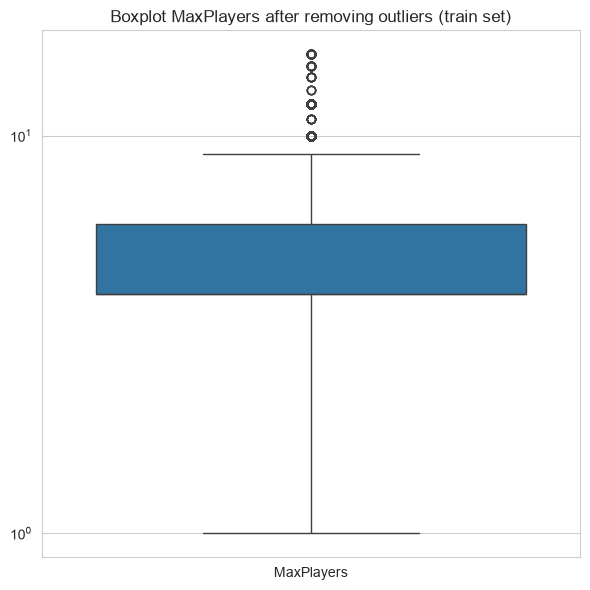

In [32]:
# boxplot of 'MaxPlayers' after removing outliers using a log scale (train set)
plt.figure(figsize=(6, 6))
sns.boxplot(data=train_df[["MaxPlayers"]])
plt.title("Boxplot MaxPlayers after removing outliers (train set)")
plt.yscale('log')
plt.tight_layout()
plt.show()

In [33]:
# turn "MinPlayers" and "MaxPlayers" to integer
for d in (train_df, test_df):
    d['MinPlayers'] = d['MinPlayers'].astype(int)
    d['MaxPlayers'] = d['MaxPlayers'].astype(int)

#### Handling ZeroValues in **'ComAgeRec'** and **'MfgAgeRec'** and dropping the 2nd one

In [34]:
# Count the zeros in ComAgeRec / MfgAgeRec, and check their correlation before fixing (train set)
zeros_ComAgeRec = (train_df['ComAgeRec'] == 0).sum()
zeros_MfgAgeRec = (train_df['MfgAgeRec'] == 0).sum()

print(f"Number of 0s in 'ComAgeRec': {zeros_ComAgeRec}")
print(f"Number of 0s in 'MfgAgeRec': {zeros_MfgAgeRec}")

corr = train_df[['ComAgeRec', 'MfgAgeRec']].corr().iloc[0, 1]
print(f"Correlation before transforming 0s in NaN: {corr:.4f}")

Number of 0s in 'ComAgeRec': 0
Number of 0s in 'MfgAgeRec': 817
Correlation before transforming 0s in NaN: 0.4522


In [35]:
# replacing 0 values with NaN in both sets
for d in (train_df, test_df):
    d["MfgAgeRec"] = d["MfgAgeRec"].replace(0, np.nan)

corr = train_df[['ComAgeRec', 'MfgAgeRec']].corr().iloc[0, 1]
print(f"Correlation after transforming 0s in NaN: {corr:.4f}")

Correlation after transforming 0s in NaN: 0.7124


In [36]:
# dropping MfgAgeRec: once 0s are treated as missing, it's highly correlated with ComAgeRec
# and therefore mostly redundant
for d in (train_df, test_df):
    d.drop(['MfgAgeRec'], axis=1, inplace=True)

#### Changing 21926 value of **Rank features** in a score (1/rank)

In [37]:
# Deterministic transform (fixed formula, no data-dependent parameters), safe for both sets
rank_columns_list = [
    'Rank:strategygames', 'Rank:abstracts', 'Rank:familygames',
    'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
    'Rank:partygames', 'Rank:childrensgames'
]
OUTLIER_VALUE = 21926

for d in (train_df, test_df):
    for col in [c for c in rank_columns_list if c in d.columns]:
        valid_mask = d[col] < OUTLIER_VALUE
        d[col] = np.where(valid_mask, 1.0 / d[col], 0.0)
        d.rename(columns={col: col.replace('Rank:', 'Score_')}, inplace=True)

print("Rank transformation complete.")

Rank transformation complete.


### **Correlation heatmap** (for numerical features only)

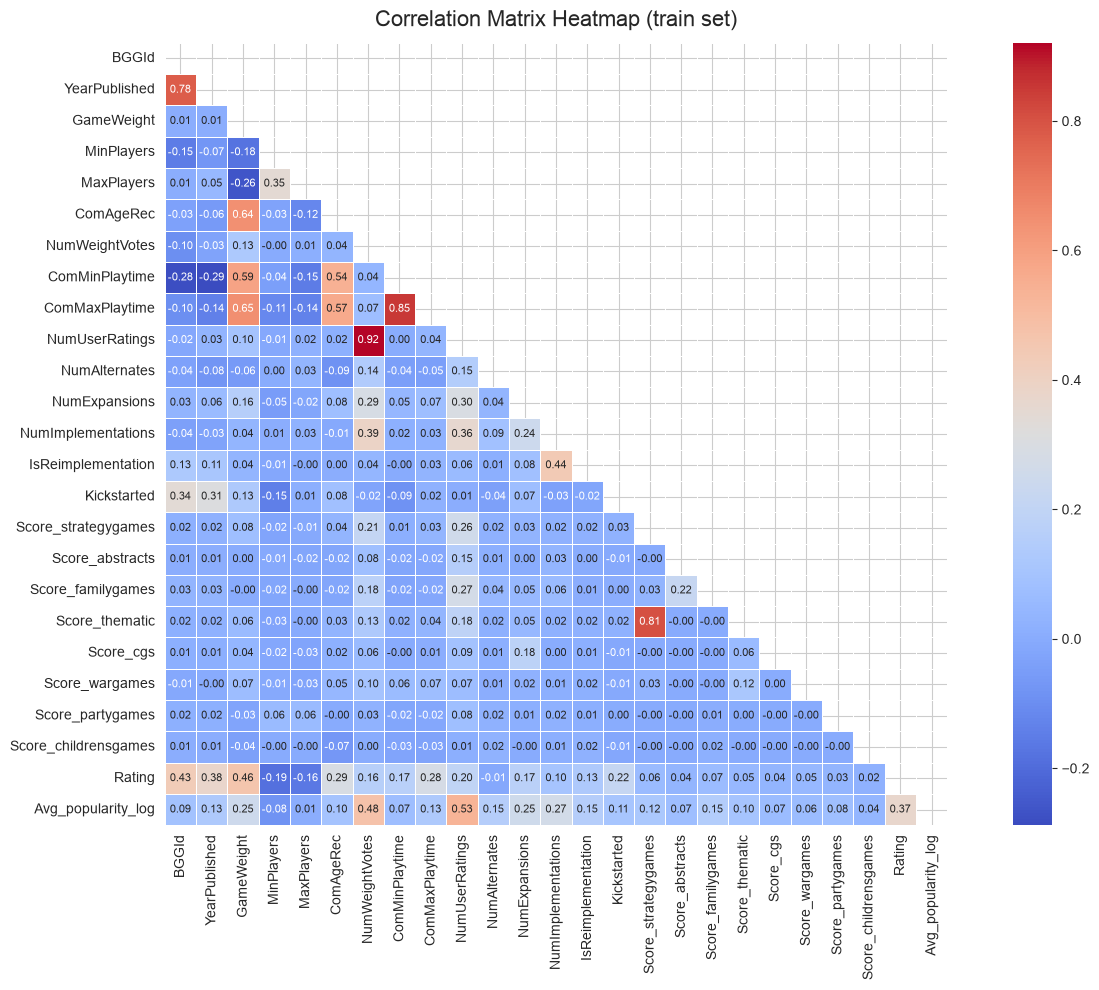

In [38]:
plot_correlation_heatmap(train_df, "Correlation Matrix Heatmap (train set)")

#### **NumAlternates, NumImplementations** and **NumExpansions**

In [39]:
ecosystem_cols = ['NumAlternates', 'NumImplementations', 'NumExpansions']

stats_list = []
for col in ecosystem_cols:
    stats_list.append({
        'Variable': col,
        'Mean': train_df[col].mean(),
        'Median': train_df[col].median(),
        'Max': train_df[col].max(),
        'Skewness': train_df[col].skew(),
        'Zero_Rate_%': (train_df[col] == 0).mean() * 100,
        'Outliers_IQR_1.5': (train_df[col] > (train_df[col].quantile(0.75) + 1.5 * (train_df[col].quantile(0.75) - train_df[col].quantile(0.25)))).sum()
    })

stats_df = pd.DataFrame(stats_list)
print(stats_df.to_string(index=False))

          Variable     Mean  Median  Max  Skewness  Zero_Rate_%  Outliers_IQR_1.5
     NumAlternates 1.430826     0.0  850 76.319234    58.850371              2508
NumImplementations 0.309335     0.0   38 12.785422    77.590468              3536
     NumExpansions 1.424361     0.0  254 14.506019    73.452057              1662


In [40]:
# Apply log transformation (log1p handles zeros: log(1+0) = 0) — deterministic, safe for both sets
for col in ecosystem_cols:
    new_col_name = f"{col}_log"
    old_skew = train_df[col].skew()

    for d in (train_df, test_df):
        d[new_col_name] = np.log1p(d[col])

    new_skew = train_df[new_col_name].skew()
    print(f"Transforming {col}:")
    print(f"  - Original Skewness: {old_skew:.2f}")
    print(f"  - Log-Transformed Skewness: {new_skew:.2f}")
    print(f"  - New Maximum Value: {train_df[new_col_name].max():.2f}\n")

Transforming NumAlternates:
  - Original Skewness: 76.32
  - Log-Transformed Skewness: 1.44
  - New Maximum Value: 6.75

Transforming NumImplementations:
  - Original Skewness: 12.79
  - Log-Transformed Skewness: 2.05
  - New Maximum Value: 3.66

Transforming NumExpansions:
  - Original Skewness: 14.51
  - Log-Transformed Skewness: 2.57
  - New Maximum Value: 5.54



In [41]:
# Remove original columns to keep the dataframe clean
for d in (train_df, test_df):
    d.drop(columns=ecosystem_cols, inplace=True)

#### Handling 'ComAgeRec' NaN values (25%)

In [42]:
# Data quality check (train set)
zero_count = (train_df['ComAgeRec'] == 0).sum()
nan_count = train_df['ComAgeRec'].isna().sum()
total_rows = len(train_df)

print("--- ComAgeRec Data Quality Check (train set) ---")
print(f"Zeros: {zero_count} ({(zero_count / total_rows) * 100:.2f}%)")
print(f"NaNs:  {nan_count} ({(nan_count / total_rows) * 100:.2f}%)")

if zero_count + nan_count == 0:
    print("\nResult: The column is perfectly clean. No zeros or missing values.")
else:
    print(f"\nResult: There are {zero_count + nan_count} missing/invalid values to handle.")

if total_rows > nan_count:
    print(f"Valid Age Range: {train_df['ComAgeRec'].min()} to {train_df['ComAgeRec'].max()}")

--- ComAgeRec Data Quality Check (train set) ---
Zeros: 0 (0.00%)
NaNs:  3760 (23.83%)

Result: There are 3760 missing/invalid values to handle.
Valid Age Range: 2.0 to 21.0


In [43]:
# Category-based imputation (medians fit on TRAIN only), using the same helper as the other columns
mask_age_nan_train = train_df['ComAgeRec'].isna()
mask_age_nan_test = test_df['ComAgeRec'].isna()
print(f"Initial NaNs in ComAgeRec: {mask_age_nan_train.sum()} (train), {mask_age_nan_test.sum()} (test)")

cat_medians, global_median = fit_category_medians(train_df, 'ComAgeRec', cat_cols, positive_only=True)
apply_category_imputation(train_df, 'ComAgeRec', cat_cols, cat_medians, global_median, mask_age_nan_train)
apply_category_imputation(test_df, 'ComAgeRec', cat_cols, cat_medians, global_median, mask_age_nan_test)

# Round the age to make it realistic (e.g., 10 instead of 10.3)
for d in (train_df, test_df):
    d['ComAgeRec'] = d['ComAgeRec'].round()

print(f"NaNs remaining: {train_df['ComAgeRec'].isna().sum()} (train)")
print(f"Final Age Range (train): {train_df['ComAgeRec'].min()} - {train_df['ComAgeRec'].max()}")

Initial NaNs in ComAgeRec: 3760 (train), 908 (test)
NaNs remaining: 0 (train)
Final Age Range (train): 2.0 - 21.0


In [44]:
# Calculate final skewness for ComAgeRec (train set)
age_skew = train_df['ComAgeRec'].skew()

print("--- Skewness Analysis for ComAgeRec (train set) ---")
print(f"Skewness Value: {age_skew:.4f}")

if abs(age_skew) < 0.5:
    print("Interpretation: The distribution is nearly symmetrical.")
elif abs(age_skew) < 1.0:
    print("Interpretation: The distribution is slightly skewed.")
else:
    print("Interpretation: The distribution is moderately to highly skewed.")

--- Skewness Analysis for ComAgeRec (train set) ---
Skewness Value: 0.0983
Interpretation: The distribution is nearly symmetrical.


#### Dropping **'NumUserRatings'** due to strongly high correlation with '**NumWeightVotes**'

In [45]:
for d in (train_df, test_df):
    d.drop(['NumUserRatings'], axis=1, inplace=True)

#### Logarithmic transformation of **NumWeightVotes** due to high skewness

In [46]:
col = 'NumWeightVotes'

mean_val = train_df[col].mean()
median_val = train_df[col].median()
max_val = train_df[col].max()
skewness = train_df[col].skew()
zero_rate = (train_df[col] == 0).mean() * 100
nan_count = train_df[col].isna().sum()

Q1 = train_df[col].quantile(0.25)
Q3 = train_df[col].quantile(0.75)
IQR = Q3 - Q1
outliers_15 = (train_df[col] > (Q3 + 1.5 * IQR)).sum()
outliers_50 = (train_df[col] > (Q3 + 5.0 * IQR)).sum()

print(f"--- Standard Analysis for {col} (train set) ---")
print(f"Mean:            {mean_val:.2f}")
print(f"Median:          {median_val:.2f}")
print(f"Max:             {max_val:.2f}")
print(f"Skewness:        {skewness:.2f}")
print(f"Zero Rate:       {zero_rate:.2f}%")
print(f"Missing (NaN):   {nan_count}")
print(f"Outliers (1.5x): {outliers_15}")
print(f"Outliers (5.0x): {outliers_50}")

--- Standard Analysis for NumWeightVotes (train set) ---
Mean:            52.74
Median:          10.00
Max:             7673.00
Skewness:        15.55
Zero Rate:       0.00%
Missing (NaN):   0
Outliers (1.5x): 2175
Outliers (5.0x): 1085


In [47]:
# Apply log transformation (deterministic, safe for both sets)
old_skew = train_df['NumWeightVotes'].skew()

for d in (train_df, test_df):
    d['NumWeightVotes_log'] = np.log1p(d['NumWeightVotes'])

new_skew = train_df['NumWeightVotes_log'].skew()

print("--- Transformation: NumWeightVotes ---")
print(f"Original Skewness: {old_skew:.2f}")
print(f"Log-Transformed Skewness: {new_skew:.2f}")
print(f"New Max Value: {train_df['NumWeightVotes_log'].max():.2f}")

--- Transformation: NumWeightVotes ---
Original Skewness: 15.55
Log-Transformed Skewness: 1.00
New Max Value: 8.95


In [48]:
# drop the original column
for d in (train_df, test_df):
    d.drop(columns=['NumWeightVotes'], inplace=True)

#### Checking redundancy between **'NumWeightVotes_log'** and **'Avg_popularity_log'**

Both are engagement/popularity proxies built from similar underlying signals, so before finalizing the feature set we check whether they're redundant enough that one can be dropped (computed on the train set only, to avoid any test-set influence on this decision).

In [49]:
corr_val = train_df[['NumWeightVotes_log', 'Avg_popularity_log']].corr().iloc[0, 1]
print(f"Correlation between NumWeightVotes_log and Avg_popularity_log (train set): {corr_val:.4f}")

CORR_THRESHOLD = 0.9
if abs(corr_val) > CORR_THRESHOLD:
    print(f"Correlation exceeds {CORR_THRESHOLD}: dropping 'NumWeightVotes_log' to avoid redundancy with 'Avg_popularity_log'.")
    for d in (train_df, test_df):
        d.drop(columns=['NumWeightVotes_log'], inplace=True)
else:
    print(f"Correlation is below {CORR_THRESHOLD}: both features carry distinct information and are kept.")

Correlation between NumWeightVotes_log and Avg_popularity_log (train set): 0.8403
Correlation is below 0.9: both features carry distinct information and are kept.


#### Dropping **'Cat:' features**

These binary category flags were kept up to this point only as auxiliary information for the category-based imputations above (playtime, MinPlayers, ComAgeRec). We drop them now because:
- 54% of games have no category at all and ~5% have more than one (see data understanding notebook), so as one-hot features they are sparse and not mutually exclusive;
- their signal is already partly absorbed into the numeric features we imputed using them.

If a future modeling notebook shows these still add predictive value on top of the imputed numeric features, they can be reintroduced with proper (multi-label) encoding at that stage.

In [50]:
for d in (train_df, test_df):
    d.drop(["Cat:Thematic", "Cat:Strategy", "Cat:War", "Cat:Family", "Cat:CGS", "Cat:Abstract", "Cat:Party", "Cat:Childrens"],
           axis=1, inplace=True)

#### Correlation matrix after cleaning

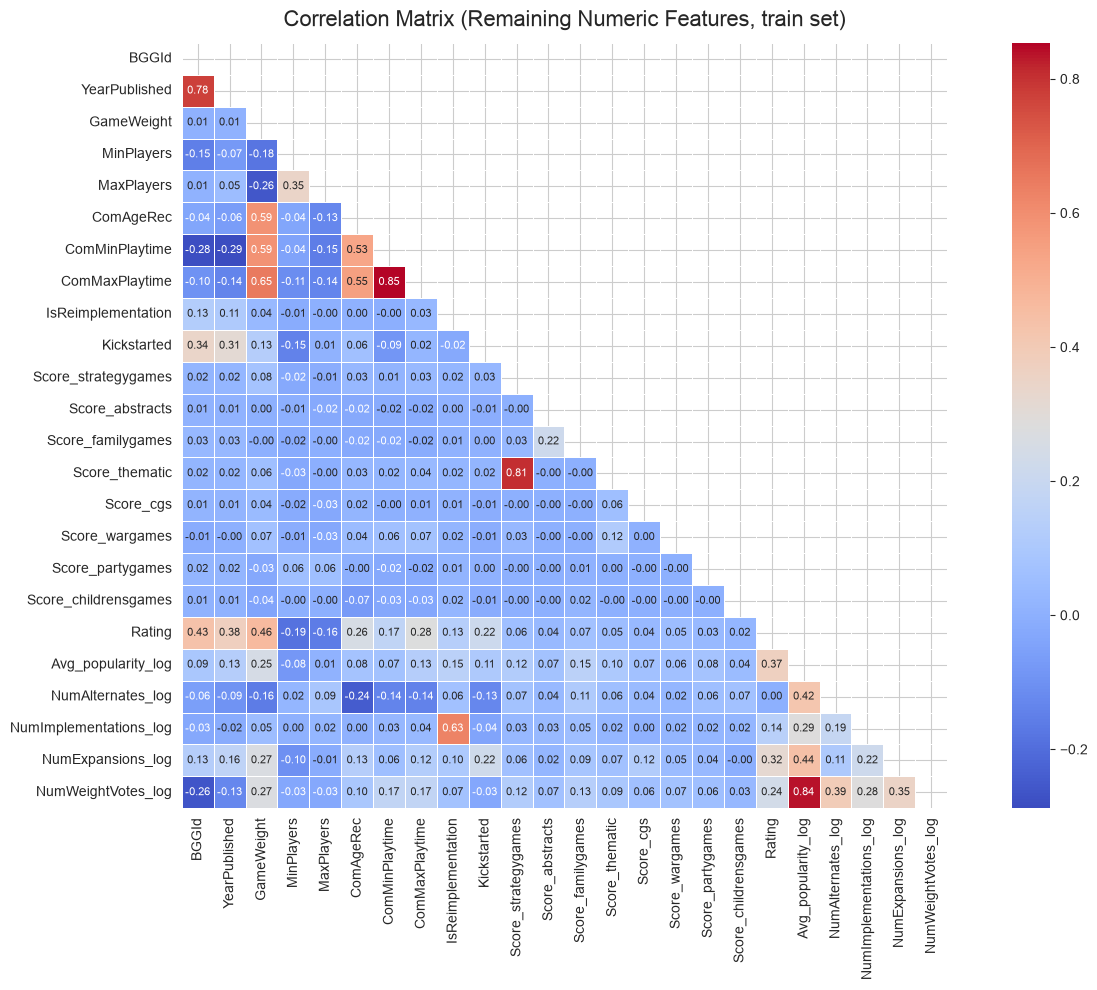

In [51]:
plot_correlation_heatmap(train_df, "Correlation Matrix (Remaining Numeric Features, train set)")

## Summary & Next Steps

### Transformations applied
- **Dropped columns**: `Description`, `BestPlayers`, `GoodPlayers`, `NumComments`, `ImagePath`, `MfgPlaytime`, `Family`, `ComWeight`, `LanguageEase`, `MfgAgeRec`, `NumUserRatings`, the original `NumAlternates`/`NumImplementations`/`NumExpansions`/`NumWeightVotes`/`Avg_popularity` (replaced by their `_log` versions), `NumWant`/`NumWish`/`NumOwned` (replaced by `Avg_popularity_log`), and all `Cat:*` flags.
- **Rows removed**: pre-1950 games, `ComMinPlaytime > ComMaxPlaytime`, playtime/MaxPlayers extreme outliers (IQR·5.0), `GameWeight == 0`, `MinPlayers > MaxPlayers`, double-zero player counts.
- **Imputed** (category-based medians, fit on train only): `ComMinPlaytime`/`ComMaxPlaytime` double zeros, residual `MinPlayers` zeros, `ComAgeRec` NaNs.
- **Engineered features**: `Avg_popularity_log`, `NumAlternates_log`/`NumImplementations_log`/`NumExpansions_log`, `NumWeightVotes_log`, `Score_*` (from `Rank:*`, as 1/rank).

### Methodology notes for whoever uses this dataset next
- The dataset was split into train/test **before** any statistic-based cleaning step, and all medians/IQR bounds were fit on the training set only, to avoid leaking test information into the pipeline.
- `Rating` was used as the stratification variable for the split, on the assumption it's the intended prediction target — if that changes, the split should be redone accordingly.
- `Cat:*` features were dropped after being used for imputation; consider revisiting this if a model shows they still carry predictive value.
- The IQR outlier multiplier (5.0 instead of the usual 1.5) was chosen deliberately for playtime/MaxPlayers to keep legitimate long-tail games while cutting clear data errors.

#### Saving the cleaned dataset

In [52]:
# Save train and test sets separately, since they were cleaned/imputed independently
# (statistics fit on train only) to prevent leakage in any downstream modeling step.
train_path = "../data/cleaned_train.csv"
test_path = "../data/cleaned_test.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Train set saved to: {train_path} ({len(train_df)} rows)")
print(f"Test set saved to:  {test_path} ({len(test_df)} rows)")

Train set saved to: ../data/cleaned_train.csv (15779 rows)
Test set saved to:  ../data/cleaned_test.csv (3950 rows)
